In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.preprocessing import FunctionTransformer


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

os.makedirs("../outputs/figures", exist_ok=True)
os.makedirs("../outputs/tables", exist_ok=True)

In [2]:
df = pd.read_csv("../data/train.csv")

print("Ham veri boyutu:", df.shape)
df.head()

Ham veri boyutu: (103904, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,2,2,2,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,4,5,5,3,3,4,4,3,3,3,0,0.0,satisfied


In [3]:
# Gereksiz sütunları kaldır
df = df.drop(columns=["Unnamed: 0", "id"])

# Eksik veriyi medyan ile doldur
df["Arrival Delay in Minutes"] = df["Arrival Delay in Minutes"].fillna(
    df["Arrival Delay in Minutes"].median()
)

# Hedef değişkeni dönüştür
df["satisfaction"] = df["satisfaction"].map({
    "neutral or dissatisfied": 0,
    "satisfied": 1
})

print("Temizlenmiş veri boyutu:", df.shape)
print("\nEksik veri toplamı:", df.isnull().sum().sum())
print("\nHedef değişken dağılımı:")
print(df["satisfaction"].value_counts())

Temizlenmiş veri boyutu: (103904, 23)

Eksik veri toplamı: 0

Hedef değişken dağılımı:
satisfaction
0    58879
1    45025
Name: count, dtype: int64


In [4]:
X = df.drop("satisfaction", axis=1)
y = df["satisfaction"]

print("X boyutu:", X.shape)
print("y boyutu:", y.shape)

X boyutu: (103904, 22)
y boyutu: (103904,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (83123, 22)
X_test: (20781, 22)
y_train: (83123,)
y_test: (20781,)


In [6]:
categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()
numeric_features = X.select_dtypes(exclude=["object", "string"]).columns.tolist()

print("Kategorik sütunlar:")
print(categorical_features)

print("\nSayısal sütunlar:")
print(numeric_features)

Kategorik sütunlar:
['Gender', 'Customer Type', 'Type of Travel', 'Class']

Sayısal sütunlar:
['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']


In [7]:
# Veri setindeki farklı sütun tiplerine farklı işlemler uygulamak için
# bir "ön işleme hattı" (preprocessor) oluşturuyoruz.

preprocessor = ColumnTransformer(
    transformers=[
        # "num" adlı dönüşüm:
        # numeric_features listesinde bulunan sayısal sütunlara StandardScaler uygula.
        # StandardScaler, sayısal değerleri benzer ölçeğe getirir
        # (ortalama yaklaşık 0, standart sapma yaklaşık 1 olur).
        ("num", StandardScaler(), numeric_features),

        # "cat" adlı dönüşüm:
        # categorical_features listesinde bulunan kategorik sütunlara
        # OneHotEncoder uygula.
        # OneHotEncoder, metinsel kategorileri modele uygun sayısal sütunlara dönüştürür.
        # handle_unknown="ignore" demek:
        # test verisinde eğitimde görülmemiş bir kategori çıkarsa hata verme.
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# preprocessor

In [8]:
def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    # Verilen modeli eğitim verisi üzerinde eğit.
    model.fit(X_train, y_train)

    # Eğitilen model ile test verisi üzerinde tahmin yap.
    y_pred = model.predict(X_test)

    # Model performans metriklerini hesapla ve bir sözlükte topla.
    metrics = {
        "Model": model_name,  # Model adı
        "Accuracy": accuracy_score(y_test, y_pred),      # Doğru tahmin oranı
        "Precision": precision_score(y_test, y_pred),    # Pozitif tahminlerin doğruluk oranı
        "Recall": recall_score(y_test, y_pred),          # Gerçek pozitifleri yakalama oranı
        "F1-score": f1_score(y_test, y_pred),            # Precision ve Recall'un dengeli ortalaması
        "F2-score": fbeta_score(y_test, y_pred, beta=2)  # Recall'a daha fazla ağırlık veren F2 skoru
    }

    # Sonuçları ekrana daha okunaklı şekilde yazdır.
    print(f"\n{model_name} Sonuçları")
    print("-" * 50)

    # Accuracy değerini ekrana yazdır.
    print(f"Accuracy: {metrics['Accuracy']:.4f}")

    # Precision değerini ekrana yazdır.
    print(f"Precision: {metrics['Precision']:.4f}")

    # Recall değerini ekrana yazdır.
    print(f"Recall: {metrics['Recall']:.4f}")

    # F1-score değerini ekrana yazdır.
    print(f"F1-score: {metrics['F1-score']:.4f}")

    # F2-score değerini ekrana yazdır.
    print(f"F2-score: {metrics['F2-score']:.4f}")

    # Confusion matrix'i yazdır.
    # Bu tablo doğru ve yanlış sınıflandırılan örnek sayılarını gösterir.
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # Hesaplanan metrikleri ve tahmin sonuçlarını geri döndür.
    # Böylece sonuçları tabloya ekleyebilir veya başka yerde kullanabiliriz.
    return metrics, y_pred

In [9]:
# Logistic Regression modeli (sadece modelin yapısını hazırlıyoruz)

log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42)) # işlenmiş veriyi Logistic Regression modeline ver
])

log_metrics, y_pred_log = evaluate_model(
    "Logistic Regression",
    log_model,
    X_train, X_test, y_train, y_test
)


Logistic Regression Sonuçları
--------------------------------------------------
Accuracy: 0.8765
Precision: 0.8692
Recall: 0.8418
F1-score: 0.8552
F2-score: 0.8471

Confusion Matrix:
[[10635  1141]
 [ 1425  7580]]


In [10]:
cm = confusion_matrix(y_test, y_pred_log)
print("Confusion Matrix:\n", cm)

tn, fp, fn, tp = cm.ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)

# F1-score hesaplama
f1 = 2 * (precision * recall) / (precision + recall)

# F2-score hesaplama
beta = 2
f2 = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"F2-score:  {f2:.4f}")

Confusion Matrix:
 [[10635  1141]
 [ 1425  7580]]
Accuracy:  0.8765
Precision: 0.8692
Recall:    0.8418
F1-score:  0.8552
F2-score:  0.8471


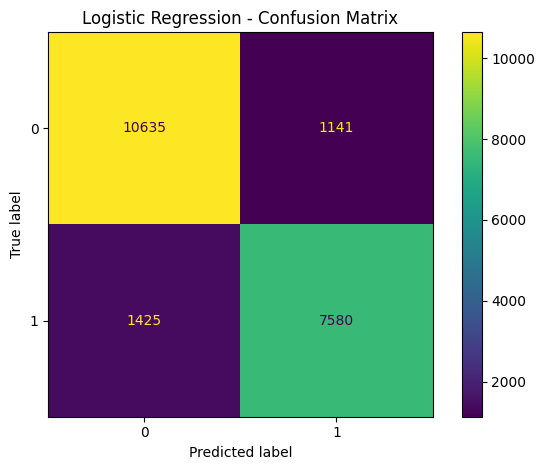

In [11]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log)
plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.savefig("../outputs/figures/confusion_matrix_lr.png", dpi=300)
plt.show()

In [12]:
# Random Forest modeli

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,   # Ağaç sayısı
        random_state=42,    # Sonuçların tekrarlanabilir olması için sabit değer
        n_jobs=-1           # Tüm işlemci çekirdeklerini kullan
    ))
])

rf_metrics, y_pred_rf = evaluate_model(
    "Random Forest",
    rf_model,
    X_train, X_test, y_train, y_test
)


Random Forest Sonuçları
--------------------------------------------------
Accuracy: 0.9642
Precision: 0.9707
Recall: 0.9460
F1-score: 0.9582
F2-score: 0.9509

Confusion Matrix:
[[11519   257]
 [  486  8519]]


In [13]:
# Confusion matrix üzerinden manuel metrik hesabı

cm = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:\n", cm)

tn, fp, fn, tp = cm.ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)

# F1-score hesaplama
f1 = 2 * (precision * recall) / (precision + recall)

# F2-score hesaplama
beta = 2
f2 = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"F2-score:  {f2:.4f}")

Confusion Matrix:
 [[11519   257]
 [  486  8519]]
Accuracy:  0.9642
Precision: 0.9707
Recall:    0.9460
F1-score:  0.9582
F2-score:  0.9509


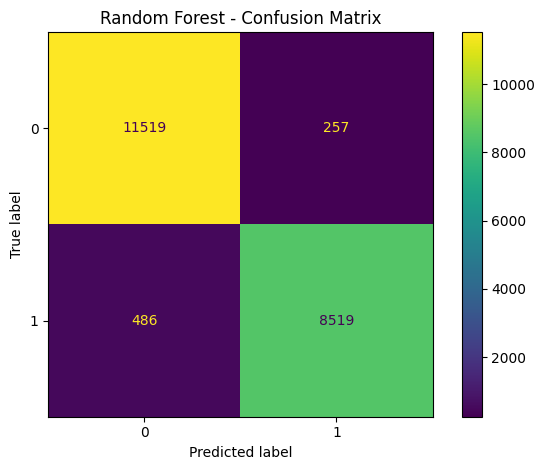

In [14]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.savefig("../outputs/figures/confusion_matrix_rf.png", dpi=300)
plt.show()

In [16]:
# kNN modeli

knn_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(
        n_neighbors=5   # En yakın 5 komşuya göre karar ver
    ))
])

knn_metrics, y_pred_knn = evaluate_model(
    "kNN",
    knn_model,
    X_train, X_test, y_train, y_test
)


kNN Sonuçları
--------------------------------------------------
Accuracy: 0.9296
Precision: 0.9423
Recall: 0.8921
F1-score: 0.9165
F2-score: 0.9017

Confusion Matrix:
[[11284   492]
 [  972  8033]]


In [17]:
# Confusion matrix üzerinden manuel hesap

cm = confusion_matrix(y_test, y_pred_knn)
print("Confusion Matrix:\n", cm)

tn, fp, fn, tp = cm.ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)

# F1-score hesaplama
f1 = 2 * (precision * recall) / (precision + recall)

# F2-score hesaplama
beta = 2
f2 = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"F2-score:  {f2:.4f}")

Confusion Matrix:
 [[11284   492]
 [  972  8033]]
Accuracy:  0.9296
Precision: 0.9423
Recall:    0.8921
F1-score:  0.9165
F2-score:  0.9017


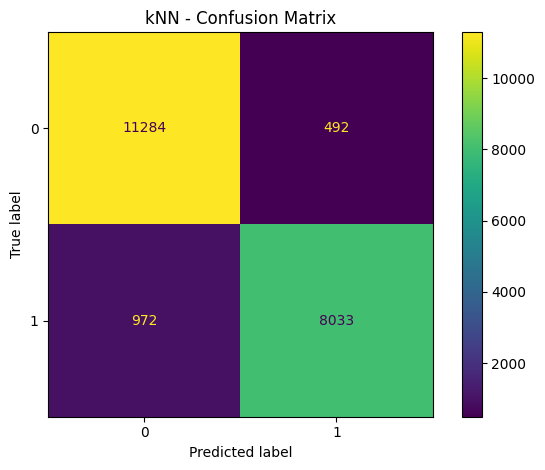

In [18]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn)
plt.title("kNN - Confusion Matrix")
plt.tight_layout()
plt.savefig("../outputs/figures/confusion_matrix_knn.png", dpi=300)
plt.show()

In [19]:
# Naive Bayes modeli

nb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GaussianNB())
])

nb_metrics, y_pred_nb = evaluate_model(
    "Naive Bayes",
    nb_model,
    X_train, X_test, y_train, y_test
)


Naive Bayes Sonuçları
--------------------------------------------------
Accuracy: 0.8499
Precision: 0.8295
Recall: 0.8228
F1-score: 0.8261
F2-score: 0.8241

Confusion Matrix:
[[10253  1523]
 [ 1596  7409]]


In [20]:
# Confusion matrix üzerinden manuel hesap

cm = confusion_matrix(y_test, y_pred_nb)
print("Confusion Matrix:\n", cm)

tn, fp, fn, tp = cm.ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)

# F1-score hesaplama
f1 = 2 * (precision * recall) / (precision + recall)

# F2-score hesaplama
beta = 2
f2 = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"F2-score:  {f2:.4f}")

Confusion Matrix:
 [[10253  1523]
 [ 1596  7409]]
Accuracy:  0.8499
Precision: 0.8295
Recall:    0.8228
F1-score:  0.8261
F2-score:  0.8241


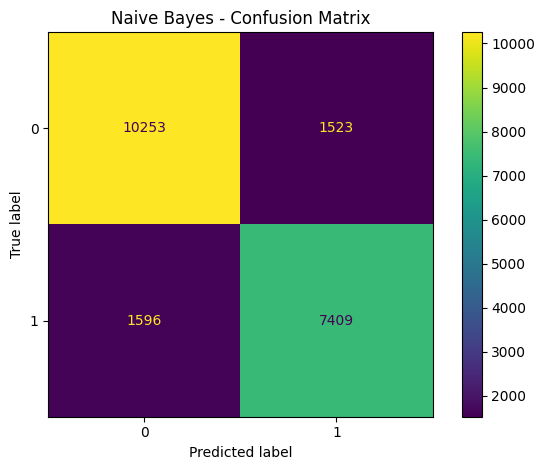

In [21]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_nb,
    values_format="d"
)
plt.title("Naive Bayes - Confusion Matrix")
plt.tight_layout()
plt.savefig("../outputs/figures/confusion_matrix_nb.png", dpi=300)
plt.show()

In [22]:
# RBF SVM modeli

rbf_svm_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", SVC(
        kernel="rbf",      # RBF kernel
        C=1.0,             # Düzenleme parametresi
        gamma="scale",     # Kernel katsayısı
        random_state=42
    ))
])

rbf_svm_metrics, y_pred_rbf_svm = evaluate_model(
    "RBF SVM",
    rbf_svm_model,
    X_train, X_test, y_train, y_test
)


RBF SVM Sonuçları
--------------------------------------------------
Accuracy: 0.9530
Precision: 0.9542
Recall: 0.9366
F1-score: 0.9453
F2-score: 0.9401

Confusion Matrix:
[[11371   405]
 [  571  8434]]


In [ ]:
# sonuç tablosu

results_df = pd.DataFrame([log_metrics, rf_metrics, knn_metrics, nb_metrics])
results_df = results_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

results_df.to_csv("../outputs/tables/model_results_internal_test.csv", index=False)
results_df

,Model,Accuracy,Precision,Recall,F1-score,F2-score
0,Random Forest,0.964246,0.970716,0.946030,0.958214,0.950866
1,kNN,0.929551,0.942287,0.892060,0.916486,0.901672
2,Logistic Regression,0.876522,0.869166,0.841755,0.855241,0.847098
3,Linear SVM,0.876426,0.869985,0.840422,0.854948,0.846173
4,Naive Bayes,0.849911,0.829489,0.822765,0.826114,0.824101


: 

: 

In [ ]:
# en iyi model
best_model_name = results_df.iloc[0]["Model"]
best_model_acc = results_df.iloc[0]["Accuracy"]

print(f"İç test sonucuna göre en iyi model: {best_model_name}")
print(f"Accuracy: {best_model_acc:.4f}")

İç test sonucuna göre en iyi model: Random Forest
Accuracy: 0.9642


: 

: 